# What this notebook is doing (Atmospheric River Events)

This notebook compares precipitation totals during a few selected AR events across the different datasets I have been using for Skagit.
The main goal is to see how each source lines up against PRISM 4 km for the same event window.

It pulls the event-period precipitation from PRISM, Daymet, HRRR, UCLA ERA5 d02, PNNL, and CONUS404, converts things to a consistent daily view where needed, and then plots the cumulative event precipitation for the basin and the main sub-basins.
It also computes MAE relative to PRISM 4 km so I can quickly see which datasets are closer or farther off for each event and region.

There are a few older versions of the workflow still kept in this notebook, but the later cells are the more complete version with the sub-basin plots and MAE output.

About the AR scale:

AR = 5 => 2003/10/15 - 2003/10/19 <br>
AR = 4 => 2006/11/05 - 2006/11/07 <br>
AR = 3 => 2016/11/05 - 2016/11/05 <br>
AR = 2 => 2018/12/16 - 2018/12/21 <br>

#### Code progress is recorded from first cell to last, to see the right output, scroll down to the last 2 code cells

In [1]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# NOW WITH SUB-BASIN PLOTS (Upper Skagit / Sauk / Lower Skagit)
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS) 
# - HRRR (monthly zarr stitched)               BASE/weather_data   NOW: HRRR F01 + HRRR F06
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn
#
# Fixes included:
# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# sub-basin plots + MAE per sub-basin
# basin_mean_daily_from_gridded() no longer throws UnboundLocalError
# consistent colors across ALL subplots (hard-coded palette)
# same y-axis scale across ALL subplots
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit


# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

# Basin boundary (still used for reference / optional)
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")

# Sub-basin polygons (HUC8)
HUC8_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/derived")
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day__SUBBASINS_gridMET.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {
        "event_year": 2021,
        "start": "2021-11-10",
        "end": "2021-11-17"
    },
    {
        "event_year": 2003,
        "start": "2003-10-18",
        "end": "2003-10-24"
    },
    {
        "event_year": 2006,
        "start": "2006-11-04",
        "end": "2006-11-10"
    },
    {
        "event_year": 2016,
        "start": "2016-10-30",
        "end": "2016-11-05"
    },
    {
        "event_year": 2018,
        "start": "2018-12-15",
        "end": "2018-12-21"
    }
]

# ============================================================
# ONE CANONICAL COLOR PALETTE 
# - Hard-coded HEX so colors never shift.
# - HRRR F01 vs HRRR F06 are different colors.
# ============================================================
DATASET_ORDER = [
    "PRISM 4km",
    "PRISM 800m",
    "Daymet-PC",
    "ORNL",
    "gridMET",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
]

COLORS = {
    # PRISM family (greens)
    "PRISM 4km":     "#1B9E77",
    "PRISM 800m":    "#66C2A5",

    # Daymet (purple)
    "Daymet-PC":     "#7570B3",
    "ORNL":          "#A65628",

    # gridMET (pinkish)
    "gridMET":       "#E7298A",

    # HRRR family (blues) — different shades per forecast hour
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",

    # UCLA ERA5 d02 (orange)
    "UCLA ERA5 d02": "#E6AB02",

    # PNNL hist (red/orange)
    "PNNL hist":     "#D95F02",

    # CONUS404 (gray)
    "CONUS404":      "#666666",
}


# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def load_subbasin_geoms():
    """
    Reads HUC8 geojson and returns dict {RegionName: shapely_geom} in EPSG:4326.
    Tries to match REGION_NAMES by name-like columns.
    """
    if not HUC8_GEO.exists():
        raise FileNotFoundError(f"Missing sub-basin geojson: {HUC8_GEO}")

    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    name_cols = [c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin", "basin", "huc_name")]
    if not name_cols:
        name_cols = [c for c in gdf.columns if "name" in c.lower()]

    if not name_cols:
        raise RuntimeError(f"Could not find a name column in {HUC8_GEO}. Columns={list(gdf.columns)}")

    name_col = name_cols[0]
    geoms = {}
    gdf["_nm_"] = gdf[name_col].astype(str).str.strip()

    for target in REGION_NAMES:
        sub = gdf[gdf["_nm_"].str.lower() == target.lower()]
        if sub.empty:
            sub = gdf[gdf["_nm_"].str.lower().str.contains(target.lower(), regex=False)]
        if sub.empty:
            raise RuntimeError(f"Could not match region '{target}' in {HUC8_GEO} using column '{name_col}'")

        try:
            geom = sub.geometry.union_all()
        except Exception:
            geom = sub.geometry.unary_union
        geoms[target] = geom

    return geoms

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily


# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))


# ============================================================
# MASKING UTIL (REGION MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _geom_key(geom):
    try:
        return geom.wkb_hex
    except Exception:
        return str(geom)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# bm is always defined or we return None safely
def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    bm = None  # ALWAYS defined

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, _geom_key(geom), d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)

            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat -> fallback to spatial mean")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                try:
                    reg = regionmask.Regions([geom])
                    rid = reg.mask(lon, lat)
                    mask_geo = ~xr.ufuncs.isnan(rid)
                    mask_np = np.asarray(mask_geo.data).astype(bool)

                    if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                        pass
                    elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                        mask_np = mask_np.T
                    else:
                        print(f"  - {label_for_print}: mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])} -> fallback mean")
                        bm = da.mean(dim=spatial, skipna=True)

                    if bm is None:
                        mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                        _MASK_CACHE[key] = mask_da
                except Exception as e:
                    print(f"  - {label_for_print}: mask build failed ({type(e).__name__}): {e} -> fallback mean")
                    bm = da.mean(dim=spatial, skipna=True)

        if bm is None:
            mask_da = _MASK_CACHE.get(key)
            if mask_da is None:
                bm = da.mean(dim=spatial, skipna=True)
            else:
                bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")



# ============================================================
# gridMET
# ============================================================

def find_gridmet_zarr_covering(year):
    p = P_GRIDMET_DIR / f"{year}_daily_4km_gridMET_data.zarr"
    if p.exists():
        return p
    return None

def load_gridmet_daily(yr, start, end, geom, region_label, do_verify=True):
    z = find_gridmet_zarr_covering(yr)
    if z is None:
        print(f"  - gridMET {yr}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = "prcp"
    if var not in ds:
        print(f"  - gridMET {yr} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"gridMET {yr} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"gridMET | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"gridMET | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, region_label, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"PRISM {tag} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily


# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, region_label, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)  # avoid multiple values for consolidated

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                region_label,
                _geom_key(geom_ll),
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            bm_daily = bm_daily.load()  # eager load

            if do_verify:
                verify_daily_and_cumsum(f"Daymet-PC | {region_label}", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

def get_ornl_zarr(year):
    if 1981 <= year <= 2011:
        p = BASE / "climate_sets" / "1981_2011_ORNL_data.zarr"
        if p.exists(): return p
    p1 = BASE / "ornl" / f"{year}_{year}_ref_DaymetV4_ORNL_data.zarr"
    if p1.exists(): return p1
    p2 = BASE / "DaymetV4" / f"{year}_{year}_ORNL_data.zarr"
    if p2.exists(): return p2
    return None

def load_ornl_daily(year, start, end, geom, region_label, do_verify=True):
    z = get_ornl_zarr(year)
    if z is None:
        print(f"  - ORNL: (not available for year {year})")
        return None

    try:
        ds = safe_open_zarr(z)
    except Exception as e:
        print(f"  - ORNL: failed to open zarr {z.name}: {e}")
        return None

    if "day" in ds.dims:
        ds = ds.rename({"day": "time"})

    var = pick_var(ds, ["prcp", "ppt", "precip"])
    if var is None:
        print(f"  - ORNL [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"ORNL | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None:
        bm_daily = ensure_daily_sum(bm_daily).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"ORNL | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily


# ============================================================
# HRRR (monthly stitched) — NOW supports selecting F01 or F06
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    """
    Converts an accumulated-looking hourly series to increments (mm/hour).
    If it doesn't look accumulated, returns unchanged.
    """
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step", "forecast_hour")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)

    # prepend 0 at first timestep so same length as original
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def _pick_hrrr_step_value(step_da: xr.DataArray, fh_hours: int):
    """
    Return a step coordinate value matching fh_hours.
    Handles step stored as timedelta64 or numeric hours.
    """
    if np.issubdtype(step_da.dtype, np.timedelta64):
        target = np.timedelta64(fh_hours, "h")
        diffs = np.abs(step_da.values - target)
        idx = int(np.argmin(diffs))
        return step_da.values[idx]

    try:
        vals = step_da.values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        return step_da.values[idx]
    except Exception:
        return step_da.values[0]

def hrrr_select_forecast_hour(da: xr.DataArray, fh_hours: int) -> xr.DataArray:
    """
    Select HRRR forecast hour from a DataArray if a forecast/step dimension exists.
    Supports dims: 'step' (most common), or 'forecast_hour'.
    """
    if "step" in da.dims:
        sv = _pick_hrrr_step_value(da["step"], fh_hours)
        out = da.sel(step=sv)
        out.attrs.update(da.attrs)
        return out

    if "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        out = da.isel(forecast_hour=idx)
        out.attrs.update(da.attrs)
        return out

    return da

def load_hrrr_daily(start, end, geom, region_label, do_verify=True, fh_hours=1):
    """
    HRRR stitched monthly zarr -> select forecast hour (F01 or F06),
    then convert to daily totals and region-mean.
    """
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, f"HRRR (stitched monthly zarr) | F{fh_hours:02d}")

    # Select forecast hour (F01 vs F06) if possible
    da = hrrr_select_forecast_hour(ds[var], fh_hours=fh_hours)

    # Convert to hourly increments if series looks accumulated
    hourly_mm = hrrr_hourly_precip_mm(xr.Dataset({var: da}), var=var)

    # Daily totals
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(
        ds_daily, var, start, end, geom,
        label_for_print=f"HRRR F{fh_hours:02d} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"HRRR F{fh_hours:02d} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily


# ============================================================
# UCLA ERA5 d02 (daily NetCDF) — per-region mask cache
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASKS = {}  # region_label -> mask2d

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, region_label, do_verify=True):
    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if region_label not in _UCLA_MASKS:
            _UCLA_MASKS[region_label] = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            m2d = _UCLA_MASKS[region_label]
            print(f"    [UCLA | {region_label}] mask cells inside: {int(m2d.sum())} / {m2d.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASKS[region_label]
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"UCLA ERA5 d02 | {region_label}", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass


# ============================================================
# PNNL hist (hourly accum → daily) — per-region mask cache
# ============================================================

_PNNL_MASKS = {}  # (region_label, grid_key) -> mask

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, region_label, do_verify=True):
    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    grid_key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    key = (region_label, grid_key)

    if key not in _PNNL_MASKS:
        _PNNL_MASKS[key] = build_pnnl_mask_for_ds(ds, geom)

    mask = _PNNL_MASKS[key]

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(mask).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label=f"PNNL hist | {region_label}").sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"PNNL hist | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily


# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask_cache = {}  # region_label -> mask

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, region_label, do_verify=True):
    global _conus_mask_cache

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if region_label not in _conus_mask_cache:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask_cache[region_label] = xr.DataArray(mask_np, dims=("y", "x"))

    mask = _conus_mask_cache[region_label]

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"CONUS404 accum | {region_label}")
    else:
        bm_daily = ensure_daily_sum(bm)

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"CONUS404 | {region_label}", bm_daily, bm_daily.cumsum("time"))
    return bm_daily


# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n


# ============================================================
# MAIN (SUB-BASIN PLOTS) + SAME Y-SCALE ACROSS ALL SUBPLOTS
# ============================================================

def main(events_to_run):
    events = events_to_run

    sub_geoms = load_subbasin_geoms()

    n_events = len(events)
    n_regions = len(REGION_NAMES)

    fig, axs = plt.subplots(
        n_regions, n_events,
        figsize=(7.5 * n_events, 4.8 * n_regions),
        squeeze=False
    )

    mae_rows = []
    global_ymax = 0.0  # force same y-scale across every subplot

    for c, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        print(f"\n================ EVENT {yr} ({start} → {end}) ================")

        for r, region in enumerate(REGION_NAMES):
            geom = sub_geoms[region]
            ax = axs[r, c]

            print(f"\n----- Region: {region} -----")

            ref_daily = load_prism_daily(start, end, "4km", geom, region, do_verify=True)

            daily_series = [
                ("PRISM 4km",       ref_daily),
                ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, region, do_verify=True)),
                ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, region, do_verify=True)),
                ("ORNL",            load_ornl_daily(yr, start, end, geom, region, do_verify=True)),
                ("gridMET",         load_gridmet_daily(yr, start, end, geom, region, do_verify=True)),
                ("HRRR F01",        load_hrrr_daily(start, end, geom, region, do_verify=True, fh_hours=1)),
                ("HRRR F06",        load_hrrr_daily(start, end, geom, region, do_verify=True, fh_hours=6)),
                ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, region, do_verify=True)),
                ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, region, do_verify=True)),
                ("CONUS404",        load_conus_daily(start, end, geom, region, do_verify=True)),
            ]

            plotted_any = False
            for label, dly in daily_series:
                if is_plottable_1d(dly):
                    cum = dly.cumsum("time")
                    x = pd.to_datetime(cum["time"].values)
                    y = np.asarray(cum.values, dtype=float)

                    ax.plot(
                        x, y,
                        label=label,
                        color=COLORS.get(label, "#000000"),  # fallback black (shouldn't happen if labels match)
                        linewidth=2.0
                    )

                    if np.isfinite(y).any():
                        global_ymax = max(global_ymax, float(np.nanmax(y)))

                    plotted_any = True

            ax.set_title(f"{yr} | {region} | Cumulative Precip")
            ax.set_xlabel("Date")
            ax.set_ylabel("Cumulative precipitation (mm)")
            ax.grid(True)
            if plotted_any:
                ax.legend(fontsize=8)

            # MAE rows (vs PRISM 4km)
            for label, dly in daily_series:
                if label == "PRISM 4km":
                    continue
                mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
                if n_days > 0 and np.isfinite(mae):
                    mae_rows.append({
                        "event_year": yr,
                        "start": start,
                        "end": end,
                        "region": region,
                        "reference": "PRISM 4km",
                        "dataset": label,
                        "mae_mm_per_day": mae,
                        "n_days": n_days,
                    })

    # force identical y-scale on every subplot
    if global_ymax > 0 and np.isfinite(global_ymax):
        ymax = global_ymax * 1.05  # small padding
        for ax in axs.ravel():
            ax.set_ylim(0, ymax)

    plt.tight_layout()
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = "ar_events_precip_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = "ar_events_precip_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = "ar_events_precip_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    yr_str = "_".join([str(ev["event_year"]) for ev in events])
    fname = f"ar_events_precip_{yr_str}_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
    mae_df.to_csv(MAE_CSV, index=False)
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)




================ EVENT 2021 (2021-11-10 → 2021-11-17) ================

----- Region: Upper Skagit -----


  - PRISM 4km [2021-01-01_2021-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'



===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 4.768206596374512
  max: 84.286865234375
  mean: 37.83521270751953
  sum: 302.68170166015625


  CHECK: daily.sum vs cum[-1]: 302.68170166015625 302.68170166015625  | diff: 0.0
  TOP 5 daily values:
    2021-11-15 84.286865234375
    2021-11-16 55.52875518798828
    2021-11-14 44.1227912902832
    2021-11-13 40.787506103515625
    2021-11-12 39.272438049316406
  - PRISM 800m: (not available)


  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'
  - Daymet-PC: (no data in window)
  - ORNL [2021_2021_ORNL_data.zarr]: var='prcp', units='mm/day'

===== VERIFY: ORNL | Upper Skagit =====
  median dt (hours): 24.00

[ORNL | Upper Skagit] DAILY CHECK
  min: 0.513617992401123
  max: 74.7494125366211
  mean: 30.165882110595703
  sum: 241.32705688476562


...

    2021-11-14 24.94890022277832
    2021-11-11 9.06937026977539
    2021-11-15 7.541542053222656
    2021-11-12 6.437959671020508
    2021-11-13 3.7615303993225098


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_standardized.png


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_standardized.png


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_standardized.png


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_2021_standardized.png


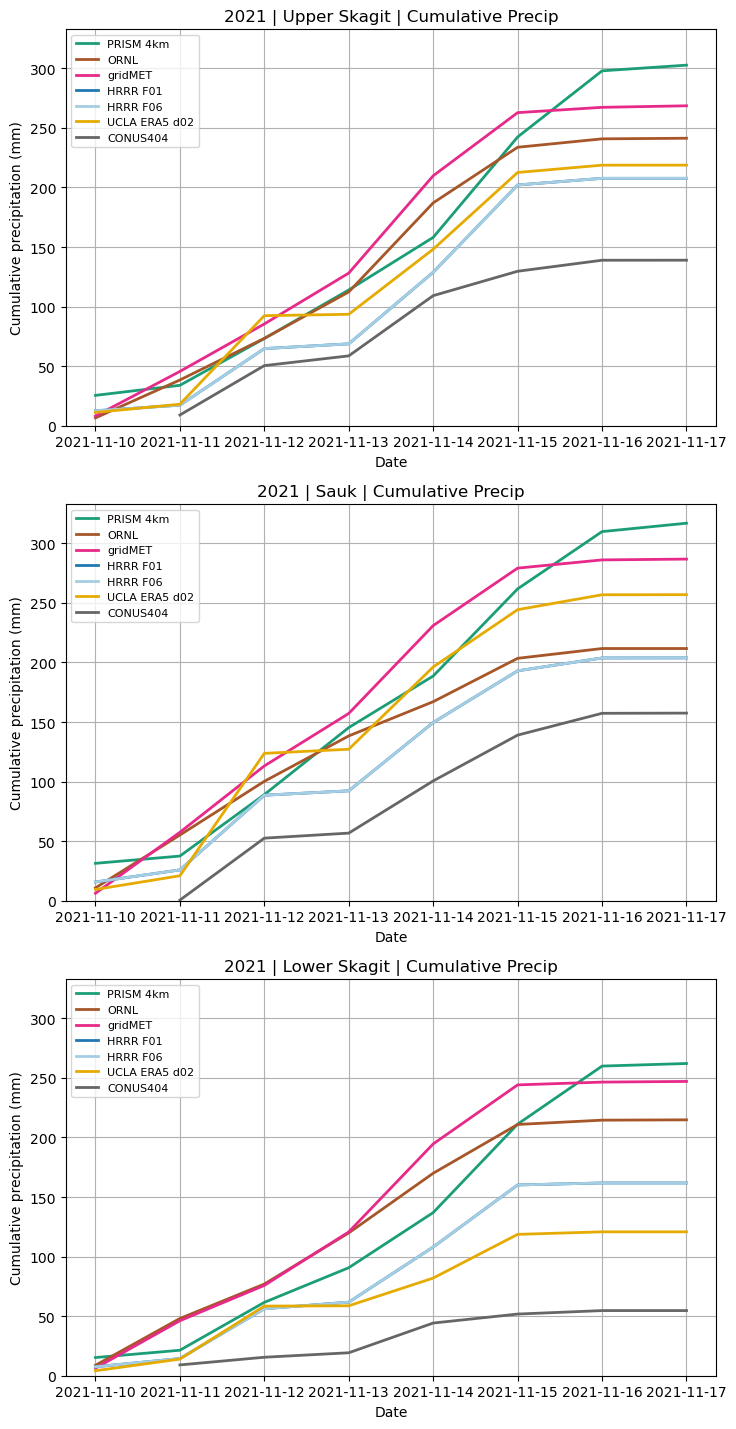


Saved MAE CSV → /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS_gridMET.csv
    event_year       start         end        region  reference  \
0         2021  2021-11-10  2021-11-17  Lower Skagit  PRISM 4km   
1         2021  2021-11-10  2021-11-17  Lower Skagit  PRISM 4km   
2         2021  2021-11-10  2021-11-17  Lower Skagit  PRISM 4km   
3         2021  2021-11-10  2021-11-17  Lower Skagit  PRISM 4km   
4         2021  2021-11-10  2021-11-17  Lower Skagit  PRISM 4km   
5         2021  2021-11-10  2021-11-17  Lower Skagit  PRISM 4km   
6         2021  2021-11-10  2021-11-17          Sauk  PRISM 4km   
7         2021  2021-11-10  2021-11-17          Sauk  PRISM 4km   
8         2021  2021-11-10  2021-11-17          Sauk  PRISM 4km   
9         2021  2021-11-10  2021-11-17          Sauk  PRISM 4km   
10        2021  2021-11-10  2021-11-17          Sauk  PRISM 4km   
11        2021  2021-11-10  2021-

In [2]:
events_2021 = [{"event_year": 2021, "start": "2021-11-10", "end": "2021-11-17"}]
main(events_2021)



================ EVENT 2003 (2003-10-18 → 2003-10-24) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2000-01-01_2009-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 4.042301177978516


  max: 120.91817474365234
  mean: 35.72061538696289
  sum: 250.04429626464844


  CHECK: daily.sum vs cum[-1]: 250.04429626464844 250.04429626464844  | diff: 0.0
  TOP 5 daily values:
    2003-10-21 120.91817474365234
    2003-10-20 52.121055603027344
    2003-10-18 36.88969421386719
    2003-10-19 12.973715782165527
    2003-10-23 11.934487342834473
  - PRISM 800m: (not available)


  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'



===== VERIFY: Daymet-PC | Upper Skagit =====
  median dt (hours): 24.00

[Daymet-PC | Upper Skagit] DAILY CHECK
  min: 0.0
  max: 115.70255279541016
  mean: 27.6086368560791
  sum: 193.2604522705078
  CHECK: daily.sum vs cum[-1]: 193.2604522705078 193.2604522705078  | diff: 0.0
  TOP 5 daily values:
    2003-10-20 115.70255279541016
    2003-10-19 30.731903076171875
    2003-10-21 16.9472713470459
    2003-10-22 13.125616073608398
    2003-10-18 9.914048194885254
  - ORNL [1981_2011_ORNL_data.zarr]: var='prcp', units='['mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/day', 'mm/

...

    2018-12-18 22.78253936767578
    2018-12-16 18.583412170410156
    2018-12-19 7.411679744720459
    2018-12-17 6.457437515258789
    2018-12-20 4.081641674041748


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_standardized.png


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_standardized.png


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_standardized.png


[PLOT] Saved to /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2/ar_events_precip_2003_2006_2016_2018_standardized.png


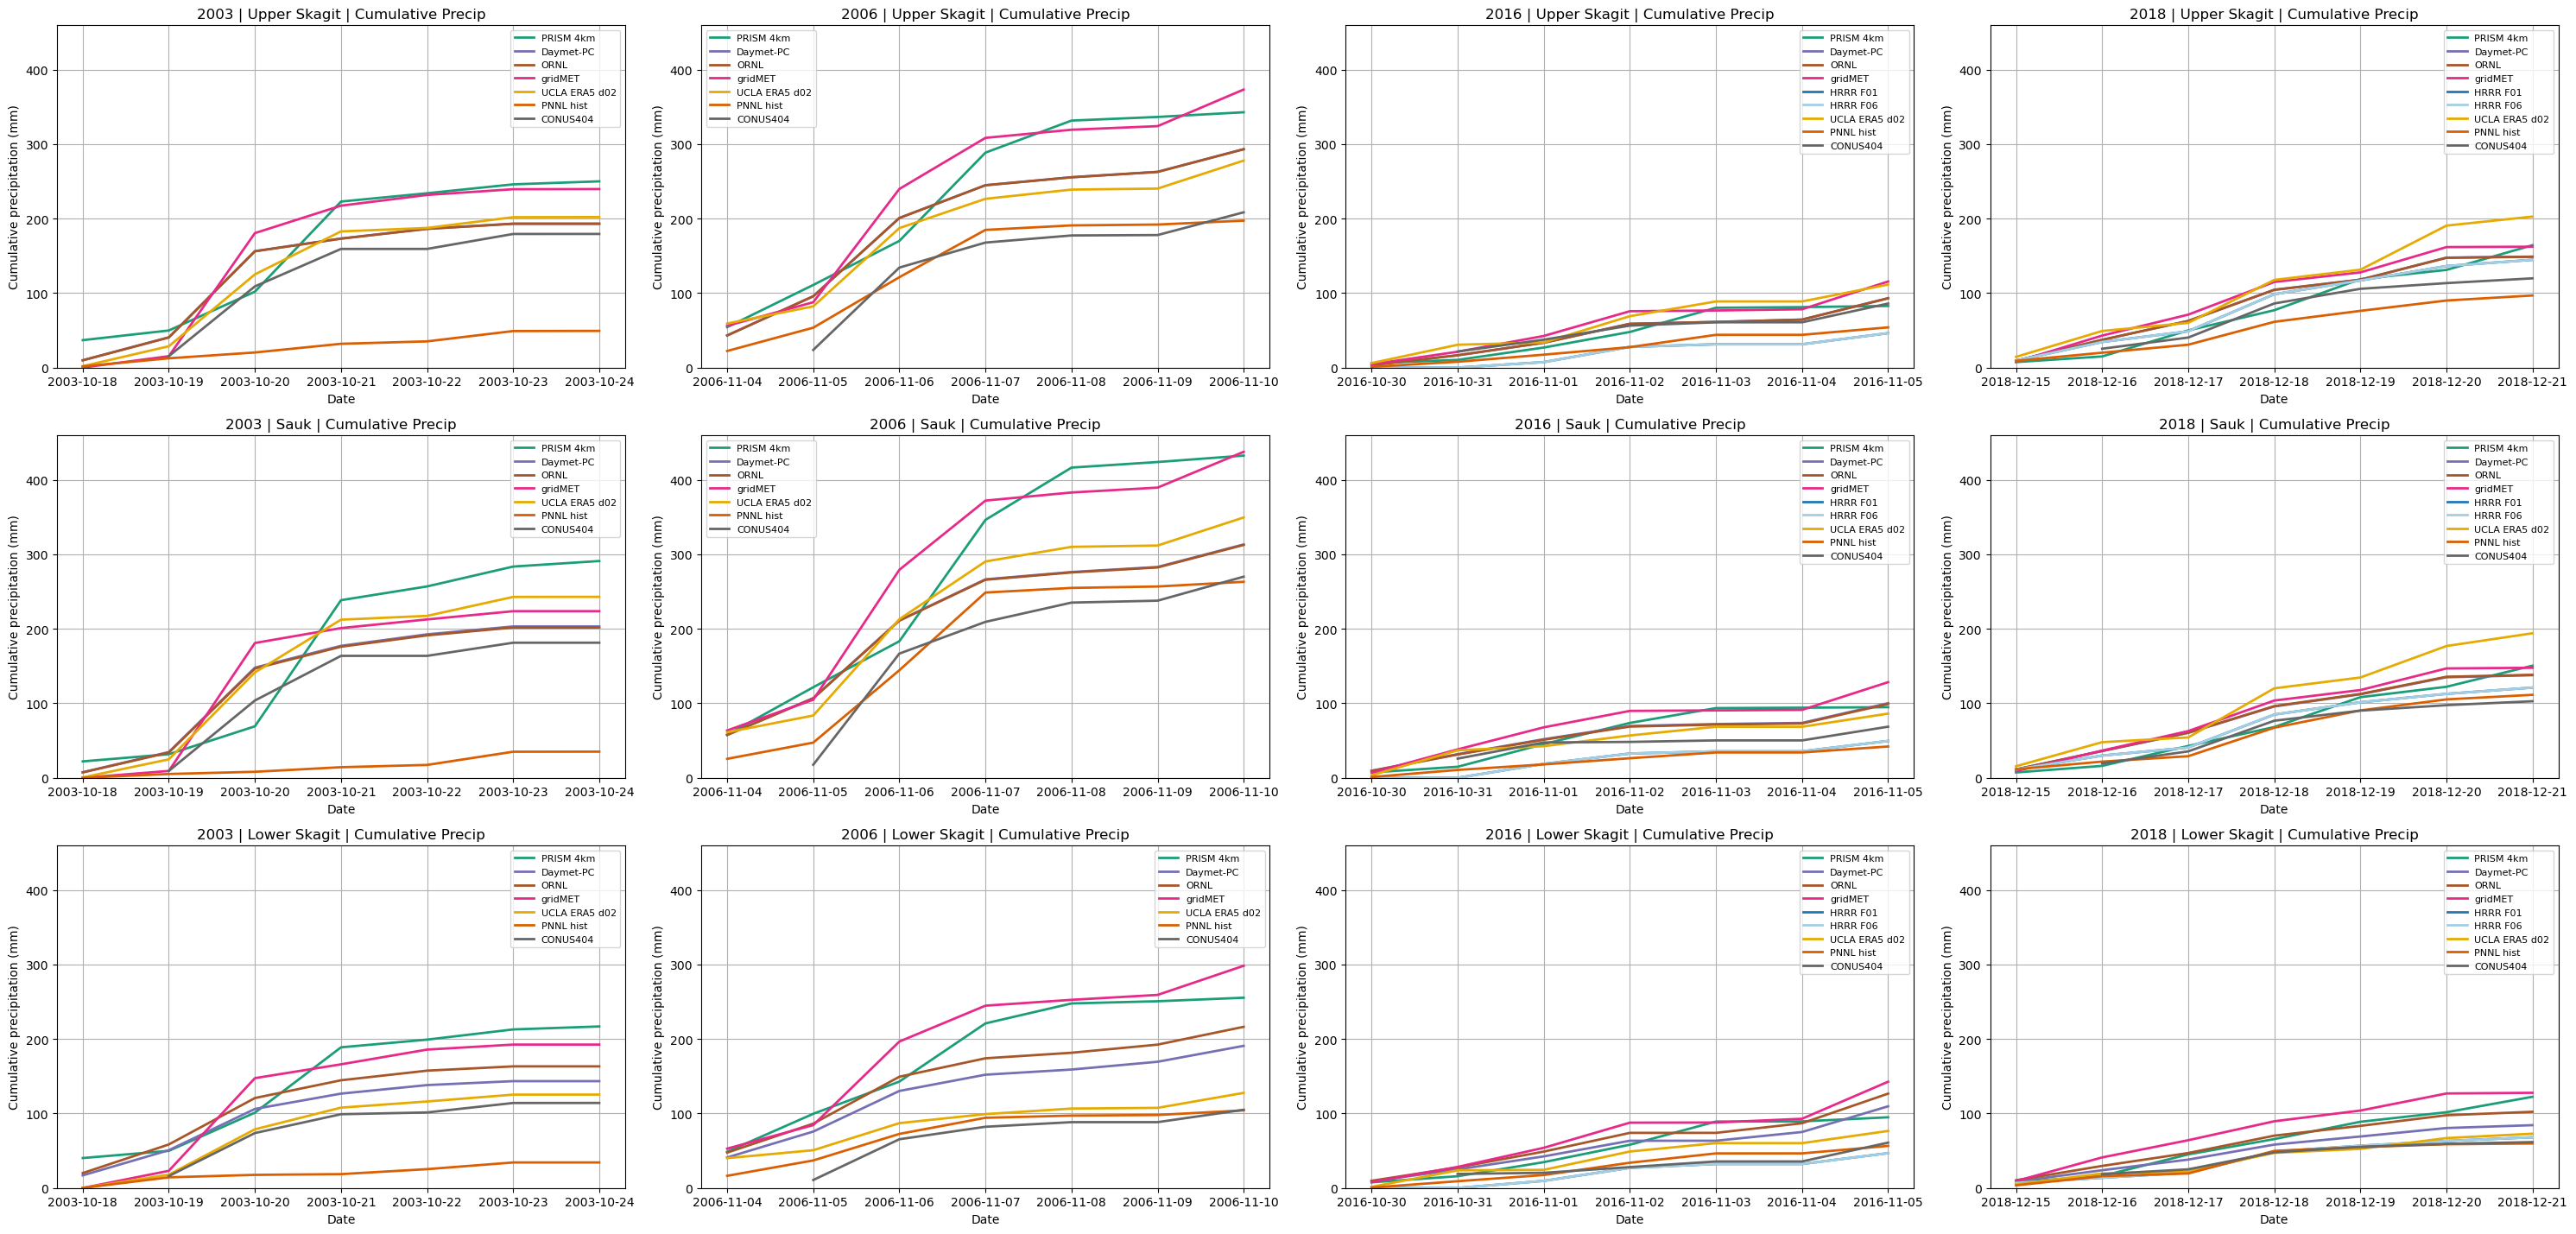


Saved MAE CSV → /home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS_gridMET.csv
    event_year       start         end        region  reference  \
0         2003  2003-10-18  2003-10-24  Lower Skagit  PRISM 4km   
1         2003  2003-10-18  2003-10-24  Lower Skagit  PRISM 4km   
2         2003  2003-10-18  2003-10-24  Lower Skagit  PRISM 4km   
3         2003  2003-10-18  2003-10-24  Lower Skagit  PRISM 4km   
4         2003  2003-10-18  2003-10-24  Lower Skagit  PRISM 4km   
..         ...         ...         ...           ...        ...   
79        2018  2018-12-15  2018-12-21  Upper Skagit  PRISM 4km   
80        2018  2018-12-15  2018-12-21  Upper Skagit  PRISM 4km   
81        2018  2018-12-15  2018-12-21  Upper Skagit  PRISM 4km   
82        2018  2018-12-15  2018-12-21  Upper Skagit  PRISM 4km   
83        2018  2018-12-15  2018-12-21  Upper Skagit  PRISM 4km   

          dataset  mae_mm_per_da

In [3]:
events_others = [{"event_year": 2003, "start": "2003-10-18", "end": "2003-10-24"}, {"event_year": 2006, "start": "2006-11-04", "end": "2006-11-10"}, {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"}, {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"}]
main(events_others)
